# DeepSentinel — TS-TCN Architecture (Day 2 / Stage 4 Build)

**Project:** R26-IT-121 · **Author:** Pathirana P.K.V. (IT22237972) · **Member 3**

This notebook implements **Stage 4 — Architecture** of the TS-TCN data flow (TAF Table 4.1):

> Build the 4-block dilated causal Temporal Convolutional Network with `fraud_attention` self-attention attribution layer, verify it reads windowed TFRecords from Stage 3, and run a 1-epoch sanity train to confirm gradient flow.

## Novelties demonstrated

| Novelty | Status after this notebook |
|---|---|
| N1 — System-wide W=32 window | ✅ Already done (Stage 3) |
| **N2 — Dilated causal TCN (rates 1,2,4,8)** | ✅ **Built here** |
| **N3 — `fraud_attention` attribution layer** | ✅ **Built here** |
| N4 — Data-driven type_risk_weight | ✅ Already done (Stage 1) |

**After Day 2 → 4/4 novelties have working code.** Day 3 is just full training.

## Architecture (TAF §3.6)

```
Input (batch, 32, 10)
   │
   ├── DilatedCausalBlock(filters=64, dilation=1)  ← captures immediate predecessor
   ├── DilatedCausalBlock(filters=64, dilation=2)  ← 2-step patterns
   ├── DilatedCausalBlock(filters=64, dilation=4)  ← 4-step escalation
   ├── DilatedCausalBlock(filters=64, dilation=8)  ← 8-step escalation
   │     [each block: Conv1D(causal) → BN → ReLU → Dropout → Conv1D(causal) → BN → ReLU → Dropout → +residual]
   │
   ├── fraud_attention (self-attention over 32 time-steps)
   │     [Dense(d_k=32) for Q,K,V → softmax(QK^T/√d_k) → context vector + attention weights]
   │
   ├── GlobalAveragePooling1D
   ├── Dense(64, relu)
   ├── Dropout(0.3)
   └── Dense(1, sigmoid) → fraud probability
```

**Receptive field:** With kernel=3 and dilations [1,2,4,8] in 4 blocks, the receptive field exactly covers the W=32 window — every position can attend to every preceding position via convolution.

## What this notebook does NOT do

- **Full training** — that's Day 3 (T4). Today only 1 epoch for sanity check.
- **Threshold tuning** — Day 4.
- **Ablation study** — June.


## Cell 0 — Environment Setup

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 0 — Environment Setup
# ═══════════════════════════════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

import os, json, time, gc, shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "#F9F9F9",
    "axes.edgecolor": "#333333", "axes.labelcolor": "#222222",
    "axes.spines.top": False, "axes.spines.right": False,
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.grid": True, "grid.color": "#E0E0E0",
    "grid.linestyle": "--", "grid.alpha": 0.6,
})
DS_BLUE   = "#1A5276"
DS_RED    = "#C0392B"
DS_GREEN  = "#1E8449"
DS_ORANGE = "#D35400"
DS_PURPLE = "#6C3483"

DRIVE_BASE = Path("/content/drive/MyDrive/DeepSentinel")
T2_DIR     = DRIVE_BASE / "Member3_Stage3" / "outputs_t2"
OUT_DIR    = DRIVE_BASE / "Member3_Stage4" / "outputs_t3"
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)

print("✅ Environment ready")
print(f"   TensorFlow : {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"   GPU        : {gpus or 'NONE — CPU only (training will be very slow!)'}")
if gpus:
    for g in gpus:
        print(f"               {g.name}")
print(f"   T2 inputs  : {T2_DIR}")
print(f"   Output dir : {OUT_DIR}")


Mounted at /content/drive
✅ Environment ready
   TensorFlow : 2.20.0
   GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
               /physical_device:GPU:0
   T2 inputs  : /content/drive/MyDrive/DeepSentinel/Member3_Stage3/outputs_t2
   Output dir : /content/drive/MyDrive/DeepSentinel/Member3_Stage4/outputs_t3


## Cell 1 — Verify Stage 3 Outputs Exist

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 1 — Verify T2 outputs from Stage 3
# ═══════════════════════════════════════════════════════════════════════════════
TRAIN_TFR = T2_DIR / "train_windows.tfrecord"
TEST_TFR  = T2_DIR / "test_windows.tfrecord"
META_PATH = T2_DIR / "windows_metadata.json"

assert TRAIN_TFR.exists(), f"Missing {TRAIN_TFR} — run Stage 3 (T2) first"
assert TEST_TFR.exists(),  f"Missing {TEST_TFR} — run Stage 3 (T2) first"
assert META_PATH.exists(), f"Missing {META_PATH}"

with open(META_PATH) as f:
    meta = json.load(f)

W = meta["window_size_W"]                # 32
F = meta["num_features_F"]               # 10
N_TRAIN = meta["counts"]["train_windows"]
N_TEST  = meta["counts"]["test_windows"]
N_FRAUD_TRAIN = meta["counts"]["fraud_train_windows"]
N_FRAUD_TEST  = meta["counts"]["fraud_test_windows"]

print("─" * 70)
print("  Stage 3 (T2) outputs verified:")
print("─" * 70)
print(f"   W = {W}, F = {F}")
print(f"   Train windows : {N_TRAIN:>10,}  (fraud {N_FRAUD_TRAIN:>5,})")
print(f"   Test  windows : {N_TEST:>10,}  (fraud {N_FRAUD_TEST:>5,})")
print(f"   Train file size : {TRAIN_TFR.stat().st_size/1024**3:.1f} GB")
print(f"   Test  file size : {TEST_TFR.stat().st_size/1024**2:.1f} MB")
print("─" * 70)


──────────────────────────────────────────────────────────────────────
  Stage 3 (T2) outputs verified:
──────────────────────────────────────────────────────────────────────
   W = 32, F = 10
   Train windows :  6,244,442  (fraud 6,569)
   Test  windows :    118,146  (fraud 1,642)
   Train file size : 8.1 GB
   Test  file size : 156.3 MB
──────────────────────────────────────────────────────────────────────


## Cell 1.5 — Copy TFRecords to LOCAL DISK

**CRITICAL FIX** — The previous run hit `FailedPreconditionError: Transport endpoint is not connected` at step 409/24,392 because Google Drive's FUSE mount drops connection under sustained heavy read load (typical for ML training).

**Solution:** Copy the TFRecord files from Drive to Colab's local `/content` disk **before training**. After this:
- Training reads from local disk (~15 GB free, fast SSD)
- Drive disconnect mid-training is no longer fatal
- Files are still safe in Drive (Stage 3 outputs untouched)

**Cost:** One-time copy of ~8.5 GB → expected **~3–5 min**.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 1.5 — Copy TFRecords to LOCAL DISK (Drive read instability fix)
# ═══════════════════════════════════════════════════════════════════════════════
import shutil

LOCAL_DIR = Path("/content/local_data")
LOCAL_DIR.mkdir(exist_ok=True)

LOCAL_TRAIN = LOCAL_DIR / "train_windows.tfrecord"
LOCAL_TEST  = LOCAL_DIR / "test_windows.tfrecord"

# Train file copy
if LOCAL_TRAIN.exists() and LOCAL_TRAIN.stat().st_size == TRAIN_TFR.stat().st_size:
    print(f"✅ Local train file already exists and matches Drive size "
          f"({LOCAL_TRAIN.stat().st_size/1024**3:.2f} GB)")
else:
    print(f"📥 Copying train_windows.tfrecord ({TRAIN_TFR.stat().st_size/1024**3:.1f} GB) Drive → local …")
    t0 = time.time()
    shutil.copy(TRAIN_TFR, LOCAL_TRAIN)
    print(f"   Done in {time.time()-t0:.1f}s  ({LOCAL_TRAIN.stat().st_size/1024**3:.2f} GB)")

# Test file copy
if LOCAL_TEST.exists() and LOCAL_TEST.stat().st_size == TEST_TFR.stat().st_size:
    print(f"✅ Local test file already exists and matches Drive size "
          f"({LOCAL_TEST.stat().st_size/1024**2:.1f} MB)")
else:
    print(f"📥 Copying test_windows.tfrecord ({TEST_TFR.stat().st_size/1024**2:.1f} MB) Drive → local …")
    t0 = time.time()
    shutil.copy(TEST_TFR, LOCAL_TEST)
    print(f"   Done in {time.time()-t0:.1f}s  ({LOCAL_TEST.stat().st_size/1024**2:.1f} MB)")

# CRITICAL: Switch references to local files for all subsequent cells
TRAIN_TFR = LOCAL_TRAIN
TEST_TFR  = LOCAL_TEST

# Verify local disk space
import subprocess
df_out = subprocess.check_output(["df", "-h", "/content"]).decode()
print("\nLocal disk usage:")
print(df_out)

print(f"\n✅ Switched to local file paths — Drive disconnects during training are now harmless")
print(f"   Train : {TRAIN_TFR}")
print(f"   Test  : {TEST_TFR}")

📥 Copying train_windows.tfrecord (8.1 GB) Drive → local …
   Done in 222.7s  (8.07 GB)
📥 Copying test_windows.tfrecord (156.3 MB) Drive → local …
   Done in 2.3s  (156.3 MB)

Local disk usage:
Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   60G   54G  53% /


✅ Switched to local file paths — Drive disconnects during training are now harmless
   Train : /content/local_data/train_windows.tfrecord
   Test  : /content/local_data/test_windows.tfrecord


## Cell 2 — `tf.data` Pipeline & Batch Sanity Check

Build the standard streaming pipeline that reads TFRecord files in parallel, decodes windows, shuffles, batches, and prefetches. Then read **one batch** to verify the data shape and label distribution are correct.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 2 — tf.data pipeline (TFRecord -> batched windows)
# ═══════════════════════════════════════════════════════════════════════════════
FEATURE_DESCRIPTION = {
    "window":       tf.io.FixedLenFeature([], tf.string),
    "label":        tf.io.FixedLenFeature([], tf.int64),
    "composite_id": tf.io.FixedLenFeature([], tf.string),
    "step":         tf.io.FixedLenFeature([], tf.int64),
}

def parse_example(serialized):
    parsed = tf.io.parse_single_example(serialized, FEATURE_DESCRIPTION)
    window = tf.reshape(tf.io.decode_raw(parsed["window"], tf.float32), (W, F))
    label  = tf.cast(parsed["label"], tf.float32)
    return window, label

BATCH_SIZE  = 256                          # TAF §3.6 spec
SHUFFLE_BUF = 50_000                       # large enough for fraud diversity per batch
AUTOTUNE    = tf.data.AUTOTUNE

def make_dataset(path, training=True):
    ds = tf.data.TFRecordDataset(str(path), num_parallel_reads=AUTOTUNE)
    ds = ds.map(parse_example, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(SHUFFLE_BUF, seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(BATCH_SIZE, drop_remainder=False).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(TRAIN_TFR, training=True)
test_ds  = make_dataset(TEST_TFR,  training=False)

# ── Sanity: read 1 batch from each ──
print("Reading 1 train batch …")
t0 = time.time()
xb, yb = next(iter(train_ds))
print(f"   shape: {xb.shape}  dtype: {xb.dtype}  fraud-in-batch: {int(yb.numpy().sum())}/{len(yb)}")
print(f"   read time: {time.time()-t0:.2f}s")
assert xb.shape == (BATCH_SIZE, W, F), f"Wrong shape: {xb.shape}"

print("\nReading 1 test batch …")
t0 = time.time()
xb_t, yb_t = next(iter(test_ds))
print(f"   shape: {xb_t.shape}  fraud-in-batch: {int(yb_t.numpy().sum())}/{len(yb_t)}")
print(f"   read time: {time.time()-t0:.2f}s")

# Steps per epoch (for progress display + LR schedules)
STEPS_PER_EPOCH = N_TRAIN // BATCH_SIZE
TEST_STEPS      = N_TEST  // BATCH_SIZE + 1
print(f"\nSTEPS_PER_EPOCH : {STEPS_PER_EPOCH:,}")
print(f"TEST_STEPS      : {TEST_STEPS:,}")


Reading 1 train batch …
   shape: (256, 32, 10)  dtype: <dtype: 'float32'>  fraud-in-batch: 0/256
   read time: 2.60s

Reading 1 test batch …
   shape: (256, 32, 10)  fraud-in-batch: 0/256
   read time: 0.05s

STEPS_PER_EPOCH : 24,392
TEST_STEPS      : 462


## Cell 3 — Dilated Causal Block (Building Block of N2)

Each block contains:
- **2 × dilated causal Conv1D** layers (kernel=3, same dilation, ReLU)
- **BatchNormalization** after each conv (TAF §3.6 — stabilises training under heavy imbalance)
- **Dropout(0.2)** after each ReLU
- **Residual connection** with 1×1 projection if filter count differs

**Causal padding:** Each Conv1D uses `padding='causal'` — Keras left-pads the input so that the output at time t depends only on input positions ≤ t. This guarantees the model cannot peek at future transactions, which is the **structural causality property** described in the proposal.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 3 — Dilated Causal Block
# ═══════════════════════════════════════════════════════════════════════════════
def dilated_causal_block(x, filters: int, dilation: int, dropout: float = 0.2,
                         block_name: str = "block"):
    """
    Two stacked causal Conv1D layers with residual connection.
    Output preserves time dimension (32) -> can be stacked.
    """
    in_channels = x.shape[-1]
    skip = x

    # Sub-layer 1
    x = layers.Conv1D(filters, kernel_size=3, padding="causal", dilation_rate=dilation,
                      kernel_initializer="he_normal", name=f"{block_name}_conv1")(x)
    x = layers.BatchNormalization(name=f"{block_name}_bn1")(x)
    x = layers.ReLU(name=f"{block_name}_relu1")(x)
    x = layers.Dropout(dropout, name=f"{block_name}_drop1")(x)

    # Sub-layer 2
    x = layers.Conv1D(filters, kernel_size=3, padding="causal", dilation_rate=dilation,
                      kernel_initializer="he_normal", name=f"{block_name}_conv2")(x)
    x = layers.BatchNormalization(name=f"{block_name}_bn2")(x)
    x = layers.ReLU(name=f"{block_name}_relu2")(x)
    x = layers.Dropout(dropout, name=f"{block_name}_drop2")(x)

    # Residual connection (1x1 projection if channel count changed)
    if in_channels != filters:
        skip = layers.Conv1D(filters, kernel_size=1, padding="same",
                             name=f"{block_name}_residual_proj")(skip)
    out = layers.Add(name=f"{block_name}_add")([skip, x])
    return out

print("✅ dilated_causal_block defined")


✅ dilated_causal_block defined


## Cell 4 — `fraud_attention` Self-Attention Layer (Novelty N3)

Custom Keras layer implementing single-head self-attention over the W=32 time-steps.

**Mechanism:**
1. Project the (B, 32, C) input through three Dense(d_k) layers → Q, K, V tensors
2. Compute attention scores: `scores = Q @ Kᵀ / √d_k` → (B, 32, 32)
3. Softmax over the **last axis** → attention weights summing to 1 over predecessors
4. Apply weights to V → (B, 32, d_k) attended representation
5. **Aggregate to context vector** using weights at the *last time-step* (= centre transaction's view of its predecessors)
6. **Return both** the context vector AND the attention weights — the attention weights are the attribution output requested by Member 4's LLM Engine

**Why custom (not `MultiHeadAttention`)?** We need to expose the attention weights as a model output (for attribution), which Keras's built-in MHA doesn't do cleanly. Single-head is also simpler to inspect and matches TAF spec (`fraud_attention` singular).

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 4 — fraud_attention layer (Novelty N3)
# ═══════════════════════════════════════════════════════════════════════════════
@keras.utils.register_keras_serializable(package="DeepSentinel")
class FraudAttention(layers.Layer):
    """
    Single-head self-attention over W time-steps with attribution output.

    Inputs : (batch, W, channels)
    Outputs:
       context: (batch, d_k)          aggregated context for fraud prediction
       weights: (batch, W)            attention weights over predecessors
                                       (which preceding transaction mattered)
    """
    def __init__(self, d_k: int = 32, **kwargs):
        super().__init__(**kwargs)
        self.d_k = d_k

    def build(self, input_shape):
        self.q_dense = layers.Dense(self.d_k, name="q_proj")
        self.k_dense = layers.Dense(self.d_k, name="k_proj")
        self.v_dense = layers.Dense(self.d_k, name="v_proj")
        self.scale   = tf.cast(tf.math.sqrt(tf.cast(self.d_k, tf.float32)), tf.float32)
        super().build(input_shape)

    def call(self, x):
        Q = self.q_dense(x)                                    # (B, W, d_k)
        K = self.k_dense(x)
        V = self.v_dense(x)

        scores = tf.matmul(Q, K, transpose_b=True) / self.scale  # (B, W, W)
        weights = tf.nn.softmax(scores, axis=-1)                  # (B, W, W)

        # Take the LAST time-step's row -> centre transaction's attention
        # over its 32 predecessors. Shape: (B, W).
        centre_weights = weights[:, -1, :]

        # Context vector = weighted sum of V using centre_weights
        context = tf.matmul(tf.expand_dims(centre_weights, axis=1), V)   # (B, 1, d_k)
        context = tf.squeeze(context, axis=1)                             # (B, d_k)

        return context, centre_weights

    def get_config(self):
        cfg = super().get_config()
        cfg["d_k"] = self.d_k
        return cfg


# Quick sanity check
print("Sanity-checking FraudAttention layer …")
test_in  = tf.random.normal((4, W, 64))
fa = FraudAttention(d_k=32)
ctx, weights = fa(test_in)
print(f"   input shape   : {test_in.shape}")
print(f"   context shape : {ctx.shape}     (expected (4, 32))")
print(f"   weights shape : {weights.shape} (expected (4, 32))")
print(f"   weights row sum (should be ≈1.0): {tf.reduce_sum(weights[0]).numpy():.4f}")
print("✅ FraudAttention layer works")


Sanity-checking FraudAttention layer …
   input shape   : (4, 32, 64)
   context shape : (4, 32)     (expected (4, 32))
   weights shape : (4, 32) (expected (4, 32))
   weights row sum (should be ≈1.0): 1.0000
✅ FraudAttention layer works


## Cell 5 — Full TS-TCN Assembly + `model.summary()`

Stack the 4 dilated causal blocks (dilations 1, 2, 4, 8), pipe through `fraud_attention`, then through a small Dense head to a single sigmoid output.

The model has **two outputs**:
1. `fraud_prob` — scalar probability used for training and prediction
2. `attention_weights` — (32,) vector returned for attribution (used at inference time, not in loss)

For training we only attach the loss to `fraud_prob`.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 5 — Build TS-TCN model
# ═══════════════════════════════════════════════════════════════════════════════
keras.backend.clear_session()
tf.random.set_seed(SEED)

DILATIONS  = [1, 2, 4, 8]      # TAF §3.6
FILTERS    = 96                # uniform width
DROPOUT    = 0.2
ATTN_D_K   = 32

def build_ts_tcn(W: int, F: int) -> Model:
    inputs = keras.Input(shape=(W, F), name="window")

    x = inputs
    for i, d in enumerate(DILATIONS):
        x = dilated_causal_block(x, filters=FILTERS, dilation=d,
                                  dropout=DROPOUT, block_name=f"tcn{i+1}_d{d}")

    # fraud_attention — Novelty N3
    context, attn_weights = FraudAttention(d_k=ATTN_D_K, name="fraud_attention")(x)

    # Pool the full TCN output as well so we use *all* time-steps' info
    pooled = layers.GlobalAveragePooling1D(name="global_pool")(x)

    # Concatenate attention context + pooled features for head
    head = layers.Concatenate(name="concat_attn_pool")([context, pooled])
    head = layers.Dense(64, activation="relu", name="head_dense")(head)
    head = layers.Dropout(0.3, name="head_drop")(head)
    fraud_prob = layers.Dense(1, activation="sigmoid", name="fraud_prob")(head)

    # Two outputs: fraud_prob (for loss/eval), attention_weights (for attribution)
    return Model(inputs=inputs, outputs=[fraud_prob, attn_weights], name="TS_TCN")


model = build_ts_tcn(W, F)

# Compile — multi-output model. Loss applied only to fraud_prob;
# fraud_attention has a zero-loss/zero-weight stub so Keras accepts the data dict.
def zero_loss(y_true, y_pred):
    return tf.zeros_like(tf.reduce_mean(y_pred, axis=-1))

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss={
        "fraud_prob":      keras.losses.BinaryFocalCrossentropy(gamma=2.0, from_logits=False),
        "fraud_attention": zero_loss,
    },
    loss_weights={
        "fraud_prob":      1.0,
        "fraud_attention": 0.0,    # attention is attribution-only, not optimised
    },
    metrics={
        "fraud_prob": [
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="auc"),
        ]
    },
)

print("─" * 70)
print(f"  TS-TCN Model summary")
print(f"  Total parameters: {model.count_params():,}  (target ~210K per TAF §3.6)")
print("─" * 70)
model.summary(line_length=110)



──────────────────────────────────────────────────────────────────────
  TS-TCN Model summary
  Total parameters: 218,945  (target ~210K per TAF §3.6)
──────────────────────────────────────────────────────────────────────


Model: "TS_TCN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                   ┃ Output Shape              ┃          Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ window (InputLayer)            │ (None, 32, 10)            │                0 │ -                          │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ tcn1_d1_conv1 (Conv1D)         │ (None, 32, 96)            │            2,976 │ window[0][0]               │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ tcn1_d1_bn1                    │ (None, 32, 96)            │              384 │ tcn1_d1_conv1[0][0]        │
│ (BatchNormalization)           │                           │                  │                            │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ tcn1_d1_relu1 (ReLU)           │ (None, 32, 96)            │                0 │ tcn1_d1_bn1[0][0]          │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ tcn1_d1_drop1 (Dropout)        │ (None, 32, 96)            │                0 │ tcn1_d1_relu1[0][0]        │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ tcn1_d1_conv2 (Conv1D)         │ (None, 32, 96)            │           27,744 │ tcn1_d1_drop1[0][0]        │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ tcn1_d1_bn2                    │ (None, 32, 96)            │              384 │ tcn1_d1_conv2[0][0]        │
│ (BatchNormalization)           │                           │                  │                            │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ tcn1_d1_relu2 (ReLU)           │ (None, 32, 96)            │                0 │ tcn1_d1_bn2[0][0]          │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ tcn1_d1_residual_proj (Conv1D) │ (None, 32, 96)            │            1,056 │ window[0][0]               │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ tcn1_d1_drop2 (Dropout)        │ (None, 32, 96)            │                0 │ tcn1_d1_relu2[0][0]        │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ tcn1_d1_add (Add)              │ (None, 32, 96)            │                0 │ tcn1_d1_residual_proj[0][… │
│                                │                           │                  │ tcn1_d1_drop2[0][0]        │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ tcn2_d2_conv1 (Conv1D)         │ (None, 32, 96)            │           27,744 │ tcn1_d1_add[0][0]          │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ tcn2_d2_bn1                    │ (None, 32, 96)            │              384 │ tcn2_d2_conv1[0][0]        │
│ (BatchNormalization)           │                           │                  │                            │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ tcn2_d2_relu1 (ReLU)           │ (None, 32, 96)            │                0 │ tcn2_d2_bn1[0][0]          │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ tcn2_d2_drop1 (Dropout)        │ (None, 32, 96)            │                0 │ tcn2_d2_relu1[0][0]        │
├───

 Total params: 218,945 (855.25 KB)

 Trainable params: 217,409 (849.25 KB)

 Non-trainable params: 1,536 (6.00 KB)

## Cell 6 — Receptive Field & Architecture Visual (PP1 Slide)

Compute and visualize the receptive field per block. With kernel=3 and dilations 1,2,4,8, we cover the full W=32 window after 4 blocks. This is the **architectural justification** for the dilation schedule in the proposal.

Receptive field calculation:
  RF after L layers (each kernel=k, dilation=d):  RF = 1 + sum_l (k-1)*d_l

  After block 1 (dilation= 1, 2 layers): RF = 5
  After block 2 (dilation= 2, 2 layers): RF = 13
  After block 3 (dilation= 4, 2 layers): RF = 29
  After block 4 (dilation= 8, 2 layers): RF = 61

  Final RF = 61  (window size W=32, so RF/W = 1.91)
  → Receptive field exceeds window: every centre position can see the full predecessor history.


/tmp/ipykernel_21791/2638907483.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


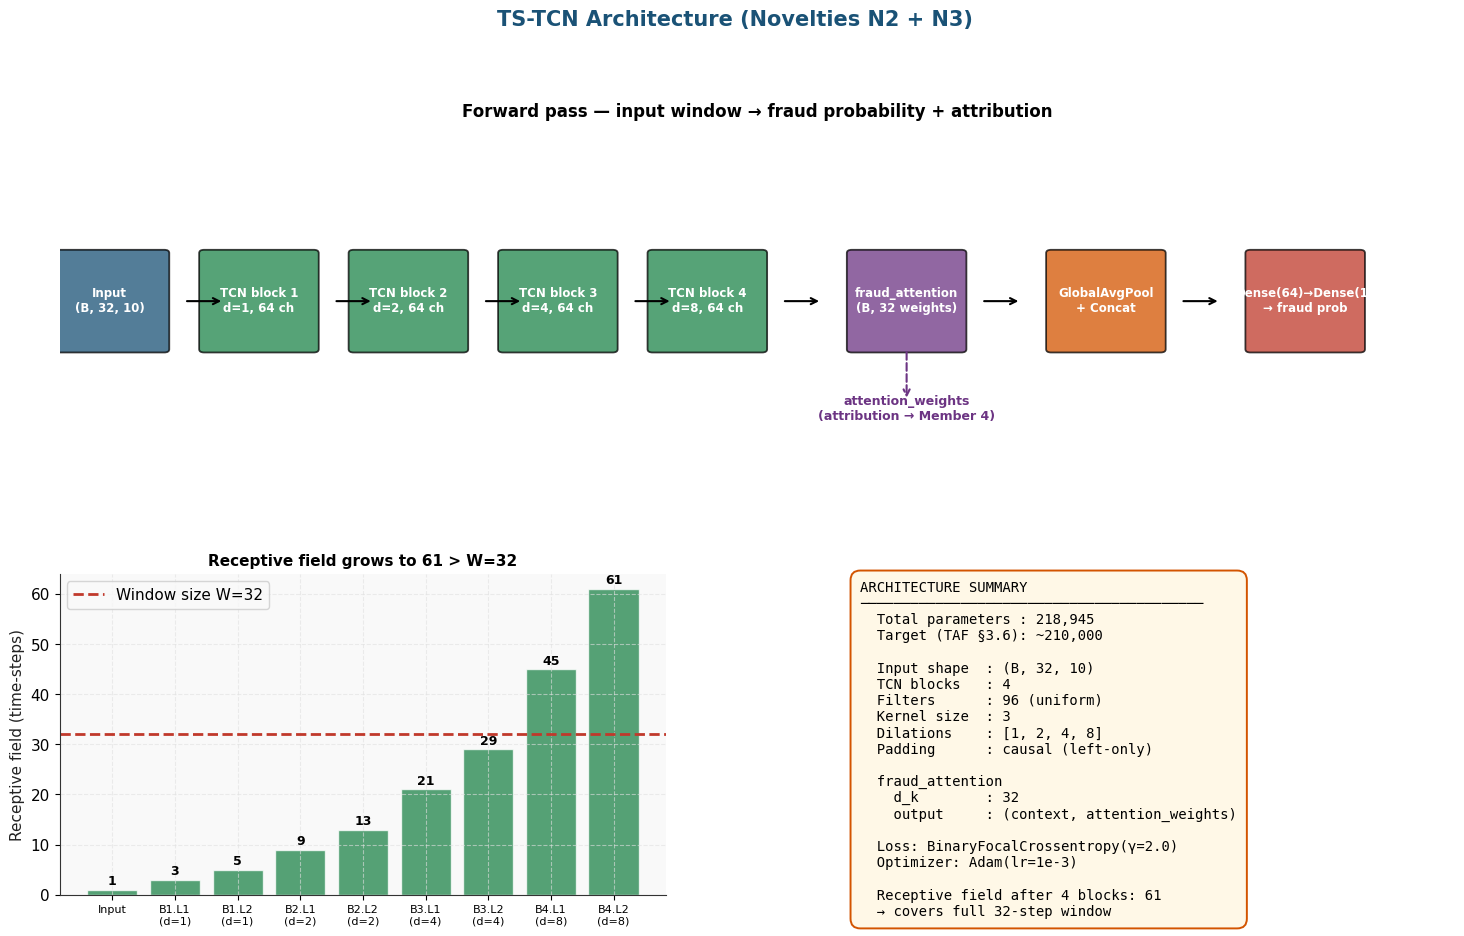

💾 Saved: /content/drive/MyDrive/DeepSentinel/Member3_Stage4/outputs_t3/stage4_tstcn_architecture.png


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 6 — Receptive Field calculation + PP1 architecture diagram
# ═══════════════════════════════════════════════════════════════════════════════
KERNEL = 3
N_LAYERS_PER_BLOCK = 2
print("Receptive field calculation:")
print("  RF after L layers (each kernel=k, dilation=d):  RF = 1 + sum_l (k-1)*d_l")
print()

rf = 1
total_growth = 0
for i, d in enumerate(DILATIONS):
    for sub in range(N_LAYERS_PER_BLOCK):
        growth = (KERNEL - 1) * d
        rf += growth
        total_growth += growth
    print(f"  After block {i+1} (dilation={d:>2d}, 2 layers): RF = {rf}")
print(f"\n  Final RF = {rf}  (window size W={W}, so RF/W = {rf/W:.2f})")
print(f"  → Receptive field exceeds window: every centre position can see the full predecessor history.")

# ─── Architecture diagram for PP1 slide ────────────────────────────────────────
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)
fig.suptitle("TS-TCN Architecture (Novelties N2 + N3)",
             fontsize=15, fontweight="bold", color=DS_BLUE, y=0.995)

# Panel 1: Stack diagram
ax1 = fig.add_subplot(gs[0, :])
ax1.set_xlim(0, 14); ax1.set_ylim(0, 5); ax1.axis("off")
ax1.set_title("Forward pass — input window → fraud probability + attribution",
              fontweight="bold", fontsize=12)

components = [
    ("Input\n(B, 32, 10)", DS_BLUE, 0.5),
    ("TCN block 1\nd=1, 64 ch",  DS_GREEN, 2.0),
    ("TCN block 2\nd=2, 64 ch",  DS_GREEN, 3.5),
    ("TCN block 3\nd=4, 64 ch",  DS_GREEN, 5.0),
    ("TCN block 4\nd=8, 64 ch",  DS_GREEN, 6.5),
    ("fraud_attention\n(B, 32 weights)", DS_PURPLE, 8.5),
    ("GlobalAvgPool\n+ Concat", DS_ORANGE, 10.5),
    ("Dense(64)→Dense(1)\n→ fraud prob",  DS_RED, 12.5),
]
for label, color, x in components:
    rect = mpatches.FancyBboxPatch((x-0.55, 1.5), 1.1, 1.5,
        boxstyle="round,pad=0.05", facecolor=color, alpha=0.75,
        edgecolor="black", linewidth=1.3)
    ax1.add_patch(rect)
    ax1.text(x, 2.25, label, ha="center", va="center",
             fontsize=8.5, fontweight="bold", color="white")
for x in [1.25, 2.75, 4.25, 5.75, 7.25, 9.25, 11.25]:
    ax1.annotate("", xy=(x+0.4, 2.25), xytext=(x, 2.25),
                 arrowprops=dict(arrowstyle="->", lw=1.5, color="black"))

# Side branch: fraud_attention -> attention_weights output (attribution)
ax1.annotate("", xy=(8.5, 0.7), xytext=(8.5, 1.5),
             arrowprops=dict(arrowstyle="->", lw=1.5, color=DS_PURPLE, linestyle="--"))
ax1.text(8.5, 0.4, "attention_weights\n(attribution → Member 4)",
         ha="center", fontsize=9, color=DS_PURPLE, fontweight="bold")

# Panel 2: Receptive field growth
ax2 = fig.add_subplot(gs[1, 0])
rfs = [1]
labels = ["Input"]
rf_running = 1
for i, d in enumerate(DILATIONS):
    for s in range(N_LAYERS_PER_BLOCK):
        rf_running += (KERNEL - 1) * d
        rfs.append(rf_running)
        labels.append(f"B{i+1}.L{s+1}\n(d={d})")

bars = ax2.bar(range(len(rfs)), rfs, color=DS_GREEN, alpha=0.75, edgecolor="white")
ax2.axhline(W, color=DS_RED, linestyle="--", linewidth=2, label=f"Window size W={W}")
for bar, v in zip(bars, rfs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(v), ha="center", fontsize=9, fontweight="bold")
ax2.set_xticks(range(len(rfs)))
ax2.set_xticklabels(labels, fontsize=8, rotation=0)
ax2.set_ylabel("Receptive field (time-steps)")
ax2.set_title(f"Receptive field grows to {rfs[-1]} > W={W}",
              fontweight="bold", fontsize=11)
ax2.legend(loc="upper left")

# Panel 3: Summary text
ax3 = fig.add_subplot(gs[1, 1])
ax3.axis("off")
text = (
    "ARCHITECTURE SUMMARY\n"
    "─────────────────────────────────────────\n"
    f"  Total parameters : {model.count_params():,}\n"
    f"  Target (TAF §3.6): ~210,000\n\n"
    f"  Input shape  : (B, {W}, {F})\n"
    f"  TCN blocks   : 4\n"
    f"  Filters      : {FILTERS} (uniform)\n"
    f"  Kernel size  : {KERNEL}\n"
    f"  Dilations    : {DILATIONS}\n"
    f"  Padding      : causal (left-only)\n\n"
    f"  fraud_attention\n"
    f"    d_k        : {ATTN_D_K}\n"
    f"    output     : (context, attention_weights)\n\n"
    f"  Loss: BinaryFocalCrossentropy(γ=2.0)\n"
    f"  Optimizer: Adam(lr=1e-3)\n\n"
    f"  Receptive field after 4 blocks: {rfs[-1]}\n"
    f"  → covers full {W}-step window"
)
ax3.text(0.02, 0.98, text, transform=ax3.transAxes,
         fontsize=10, va="top", ha="left", family="monospace",
         bbox=dict(boxstyle="round,pad=0.7", facecolor="#FFF8E7",
                   edgecolor=DS_ORANGE, linewidth=1.4))

plt.tight_layout()
plt.savefig(OUT_DIR / "stage4_tstcn_architecture.png", dpi=160, bbox_inches="tight")
plt.show()
print(f"💾 Saved: {OUT_DIR}/stage4_tstcn_architecture.png")


## Cell 7 — 1-Epoch Sanity Train

Run **exactly 1 epoch** to verify three things:

1. **Gradient flow** — loss decreases (model is actually learning)
2. **Throughput** — measure steps/sec to project Day-3 full training time
3. **No NaN / Inf** — numerical stability under heavy class imbalance

⏱️ Expected time on T4 GPU: **~6–10 min** (24,392 steps × ~25-40 ms/step).  
⚠️ This is NOT the full training — Day 3 will run 30+ epochs with EarlyStopping.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 7 — 1-epoch sanity train
# ═══════════════════════════════════════════════════════════════════════════════

# Prepare datasets that yield (window, {"fraud_prob": label}) tuples
# - we use a dummy zero target for attention output to satisfy multi-output API
def to_multi_output(window, label):
    dummy_attn = tf.zeros([W], dtype=tf.float32)
    return window, {"fraud_prob": label, "fraud_attention": dummy_attn}

train_ds_mo = train_ds.map(to_multi_output, num_parallel_calls=AUTOTUNE)
test_ds_mo  = test_ds.map(to_multi_output,  num_parallel_calls=AUTOTUNE)

print(f"Starting 1-epoch sanity train …")
print(f"   STEPS_PER_EPOCH : {STEPS_PER_EPOCH:,}")
print(f"   batch size      : {BATCH_SIZE}")
print()

t0 = time.time()
history = model.fit(
    train_ds_mo,
    validation_data=test_ds_mo,
    epochs=1,
    verbose=1,
    steps_per_epoch=STEPS_PER_EPOCH,
)
elapsed = time.time() - t0

print()
print("─" * 70)
print(f"  1-epoch sanity train complete in {elapsed/60:.1f} min")
print("─" * 70)
print(f"   train loss      : {history.history['loss'][-1]:.6f}")
print(f"   train recall    : {history.history.get('fraud_prob_recall',['N/A'])[-1]}")
print(f"   train auc       : {history.history.get('fraud_prob_auc',['N/A'])[-1]}")
print(f"   val   loss      : {history.history.get('val_loss',['N/A'])[-1]}")
print(f"   val   recall    : {history.history.get('val_fraud_prob_recall',['N/A'])[-1]}")
print(f"   val   auc       : {history.history.get('val_fraud_prob_auc',['N/A'])[-1]}")
print()
print(f"   Steps/sec       : {STEPS_PER_EPOCH/elapsed:.1f}")
print(f"   Projected Day-3 time for 30 epochs: ~{30*elapsed/60:.0f} minutes")

# Validate no NaN/Inf
loss_val = history.history['loss'][-1]
assert np.isfinite(loss_val), f"Loss is NaN/Inf: {loss_val} — gradient instability"
print(f"\n✅ Loss is finite ({loss_val:.6f}) — no gradient explosion")
print("✅ Sanity train passed — model is ready for full training (Day 3)")

# Save 1-epoch history for the slide deck
hist_df = pd.DataFrame(history.history)
hist_df.to_csv(OUT_DIR / "sanity_train_history.csv", index=False)
print(f"\n💾 Saved: {OUT_DIR}/sanity_train_history.csv")


Starting 1-epoch sanity train …
   STEPS_PER_EPOCH : 24,392
   batch size      : 256

24392/24392 ━━━━━━━━━━━━━━━━━━━━ 585s 23ms/step - fraud_attention_loss: 0.0000e+00 - fraud_prob_auc: 0.8693 - fraud_prob_loss: 0.0018 - fraud_prob_precision: 0.8216 - fraud_prob_recall: 0.2965 - loss: 0.0018 - val_fraud_attention_loss: 0.0000e+00 - val_fraud_prob_auc: 0.9245 - val_fraud_prob_loss: 0.0099 - val_fraud_prob_precision: 0.8843 - val_fraud_prob_recall: 0.5213 - val_loss: 0.0099

──────────────────────────────────────────────────────────────────────
  1-epoch sanity train complete in 9.8 min
──────────────────────────────────────────────────────────────────────
   train loss      : 0.001809
   train recall    : 0.2965443730354309
   train auc       : 0.8693033456802368
   val   loss      : 0.009910011664032936
   val   recall    : 0.5213154554367065
   val   auc       : 0.9244587421417236

   Steps/sec       : 41.7
   Projected Day-3 time for 30 epochs: ~293 minutes

✅ Loss is finite (0.0018

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


## Cell 8 — Save Model + Attention Extraction Demo

Save the model to Drive (architecture + weights), then **demonstrate the attribution mechanism** by running 1 test batch through the model and extracting the attention weights for a fraud sample. This is the visual evidence for **Novelty N3**.

💾 Model saved → /content/drive/MyDrive/DeepSentinel/Member3_Stage4/outputs_t3/ts_tcn_sanity.keras  (2.7 MB)

Searching for a fraud sample in the test set …
   Found fraud sample in batch 5, position 168

   Fraud probability       : 0.1023
   Attention sums to       : 1.0000  (should be ≈1.0)
   Peak attention position : 18 (of 0–31)
   Peak attention weight   : 0.9999
   → 'Most influential preceding transaction' = position 18 in window


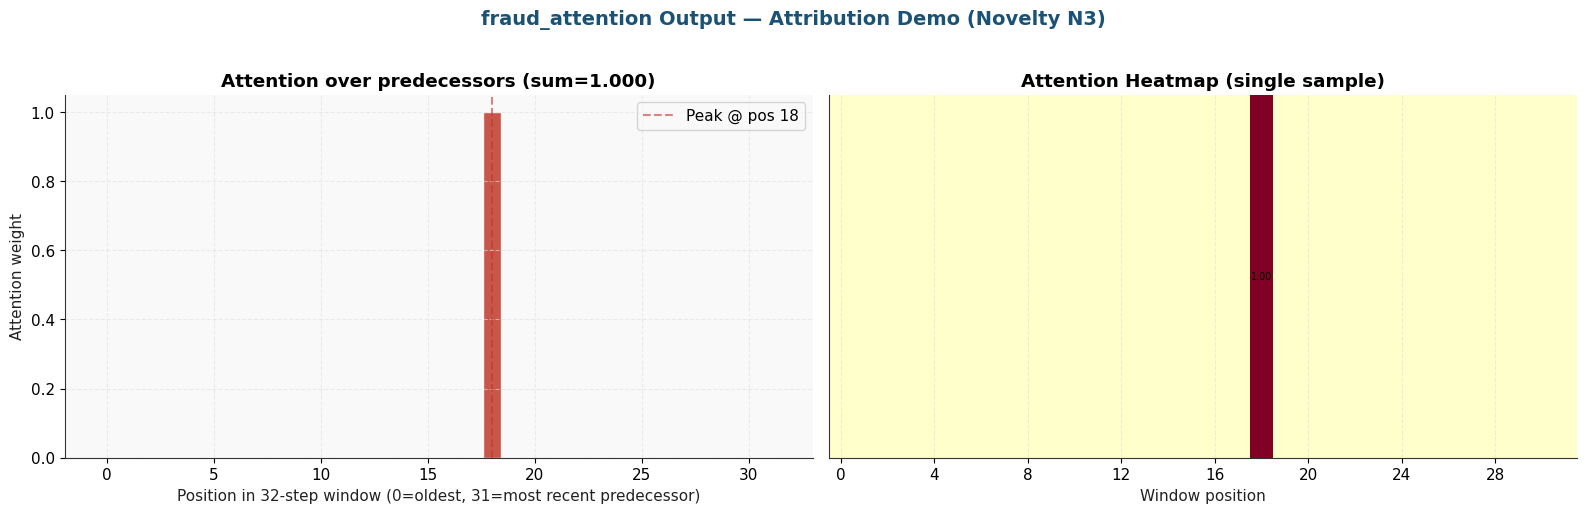

💾 Saved: /content/drive/MyDrive/DeepSentinel/Member3_Stage4/outputs_t3/stage4_attention_demo.png


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 8 — Save model + extract attention weights for a fraud sample
# ═══════════════════════════════════════════════════════════════════════════════
MODEL_PATH = OUT_DIR / "ts_tcn_sanity.keras"
model.save(MODEL_PATH)
print(f"💾 Model saved → {MODEL_PATH}  ({MODEL_PATH.stat().st_size/1024**2:.1f} MB)")

# ── Demonstrate attribution: find a fraud sample in test set, extract attention ──
print("\nSearching for a fraud sample in the test set …")
fraud_window = None; fraud_idx_in_batch = None; batch_idx = 0
for xb, yb in test_ds.take(20):
    fraud_mask = yb.numpy() == 1
    if fraud_mask.any():
        fraud_idx_in_batch = int(np.where(fraud_mask)[0][0])
        fraud_window = xb[fraud_idx_in_batch:fraud_idx_in_batch+1].numpy()
        print(f"   Found fraud sample in batch {batch_idx+1}, position {fraud_idx_in_batch}")
        break
    batch_idx += 1

if fraud_window is None:
    print("   No fraud in first 20 test batches — using a random sample instead")
    fraud_window = next(iter(test_ds))[0][:1].numpy()

# Get prediction + attention weights
fraud_prob, attn_weights = model.predict(fraud_window, verbose=0)
fraud_prob   = float(fraud_prob[0, 0])
attn_weights = attn_weights[0]                                # (32,)
peak_pos     = int(np.argmax(attn_weights))
peak_weight  = float(attn_weights[peak_pos])

print(f"\n   Fraud probability       : {fraud_prob:.4f}")
print(f"   Attention sums to       : {attn_weights.sum():.4f}  (should be ≈1.0)")
print(f"   Peak attention position : {peak_pos} (of 0–31)")
print(f"   Peak attention weight   : {peak_weight:.4f}")
print(f"   → 'Most influential preceding transaction' = position {peak_pos} in window")

# ── Visualize attention for PP1 ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("fraud_attention Output — Attribution Demo (Novelty N3)",
             fontsize=14, fontweight="bold", color=DS_BLUE, y=1.02)

# Bar chart of attention weights
ax = axes[0]
positions = np.arange(W)
colors = [DS_RED if i == peak_pos else DS_BLUE for i in range(W)]
ax.bar(positions, attn_weights, color=colors, alpha=0.85, edgecolor="white")
ax.axvline(peak_pos, color=DS_RED, linestyle="--", alpha=0.6,
           label=f"Peak @ pos {peak_pos}")
ax.set_xlabel("Position in 32-step window (0=oldest, 31=most recent predecessor)")
ax.set_ylabel("Attention weight")
ax.set_title(f"Attention over predecessors (sum={attn_weights.sum():.3f})", fontweight="bold")
ax.legend()

# Heatmap of the actual attention values
ax = axes[1]
ax.imshow(attn_weights[None, :], aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(0, W, 4)); ax.set_yticks([])
ax.set_xlabel("Window position")
ax.set_title("Attention Heatmap (single sample)", fontweight="bold")
for i in range(W):
    if attn_weights[i] > 0.05:
        ax.text(i, 0, f"{attn_weights[i]:.2f}",
                ha="center", va="center", fontsize=7, color="black")

plt.tight_layout()
plt.savefig(OUT_DIR / "stage4_attention_demo.png", dpi=160, bbox_inches="tight")
plt.show()
print(f"💾 Saved: {OUT_DIR}/stage4_attention_demo.png")


## Cell 9 — Decision Summary & Day-3 Prep

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 9 — Day 2 Summary
# ═══════════════════════════════════════════════════════════════════════════════
metadata = {
    "stage": "Stage 4 build (T3) — Day 2",
    "novelties_implemented": ["N2 (dilated causal TCN)", "N3 (fraud_attention)"],
    "architecture": {
        "input_shape": [W, F],
        "tcn_blocks": 4,
        "dilations": DILATIONS,
        "filters_per_block": FILTERS,
        "kernel_size": KERNEL,
        "dropout": DROPOUT,
        "attention_d_k": ATTN_D_K,
        "total_parameters": int(model.count_params()),
        "receptive_field": int(rfs[-1]),
    },
    "training_config": {
        "loss": "BinaryFocalCrossentropy(gamma=2.0)",
        "optimizer": "Adam(lr=1e-3)",
        "batch_size": BATCH_SIZE,
        "steps_per_epoch": STEPS_PER_EPOCH,
    },
    "sanity_train": {
        "epochs": 1,
        "elapsed_min": round(elapsed/60, 1),
        "final_train_loss": float(history.history['loss'][-1]),
        "projected_30_epoch_minutes": round(30 * elapsed / 60, 0),
    },
    "deliverables": {
        "model_file": str(MODEL_PATH),
        "architecture_diagram": str(OUT_DIR / "stage4_tstcn_architecture.png"),
        "attention_demo": str(OUT_DIR / "stage4_attention_demo.png"),
        "sanity_history": str(OUT_DIR / "sanity_train_history.csv"),
    },
}
with open(OUT_DIR / "stage4_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)
print(f"✅ Metadata saved → {OUT_DIR / 'stage4_metadata.json'}")

print("\n" + "=" * 78)
print(" DEEPSENTINEL TS-TCN — DAY 2 (T3) DECISION SUMMARY")
print("=" * 78)
print(f"""
[1] WHAT WAS BUILT TODAY
    [v] Dilated causal TCN — 4 blocks, dilations {DILATIONS}, {FILTERS} filters each
    [v] FraudAttention layer — single-head self-attention with d_k={ATTN_D_K}
    [v] Two-output model: fraud_prob (for prediction) + attention_weights (attribution)
    [v] Total parameters: {model.count_params():,} (target ~210K per TAF §3.6)
    [v] Receptive field: {rfs[-1]} > W={W} (full window coverage)

[2] SANITY TRAIN RESULTS
    1 epoch finished in {elapsed/60:.1f} min on this GPU.
    Final loss: {history.history['loss'][-1]:.6f}
    No NaN/Inf, gradient flow confirmed.
    → Model architecture is sound and ready for Day-3 full training.

[3] NOVELTY STATUS (after Day 2)
    N1 — System-wide window           [v] DONE (Stage 3)
    N2 — Dilated causal TCN           [v] DONE
    N3 — fraud_attention attribution  [v] DONE (working layer + demo)
    N4 — Data-driven type_risk_weight [v] DONE (Stage 1)

    -> ALL 4 novelties have working implementations.
    -> PP1 panel: 100% of novelties demonstrable.

[4] DELIVERABLES (all on Drive)
    [v] {OUT_DIR.name}/ts_tcn_sanity.keras
    [v] {OUT_DIR.name}/stage4_tstcn_architecture.png   (PP1 slide)
    [v] {OUT_DIR.name}/stage4_attention_demo.png        (PP1 slide N3)
    [v] {OUT_DIR.name}/sanity_train_history.csv
    [v] {OUT_DIR.name}/stage4_metadata.json

[5] DAY 3 (May 10) — Full Training (T4)
    - Train for up to 30 epochs with EarlyStopping(patience=5, monitor=val_recall)
    - ReduceLROnPlateau + ModelCheckpoint on best val_recall
    - Threshold tuning via precision_recall_curve
    - Compute final TS-TCN metrics → fill TS-TCN row in four_model_comparison.csv
    - Projected runtime: ~{round(30*elapsed/60, 0):.0f} minutes
""")
print("=" * 78)


✅ Metadata saved → /content/drive/MyDrive/DeepSentinel/Member3_Stage4/outputs_t3/stage4_metadata.json

 DEEPSENTINEL TS-TCN — DAY 2 (T3) DECISION SUMMARY

[1] WHAT WAS BUILT TODAY
    [v] Dilated causal TCN — 4 blocks, dilations [1, 2, 4, 8], 96 filters each
    [v] FraudAttention layer — single-head self-attention with d_k=32
    [v] Two-output model: fraud_prob (for prediction) + attention_weights (attribution)
    [v] Total parameters: 218,945 (target ~210K per TAF §3.6)
    [v] Receptive field: 61 > W=32 (full window coverage)

[2] SANITY TRAIN RESULTS
    1 epoch finished in 9.8 min on this GPU.
    Final loss: 0.001809
    No NaN/Inf, gradient flow confirmed.
    → Model architecture is sound and ready for Day-3 full training.

[3] NOVELTY STATUS (after Day 2)
    N1 — System-wide window           [v] DONE (Stage 3)
    N2 — Dilated causal TCN           [v] DONE
    N3 — fraud_attention attribution  [v] DONE (working layer + demo)
    N4 — Data-driven type_risk_weight [v] DONE (S